# Relative Vigor Index — a quantitative teardown 🔬
### Mechanical RVI on 5 indices · cross-up forward returns · one-sample HAC *t* · a drift-matched random-entry baseline · a phase-scramble timing placebo · costs · a synthetic planted-regime control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![RVI_cross_forecasts%3F: Busted](https://img.shields.io/badge/RVI_cross_forecasts%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **cross** from the **drift**: an upward-trending index makes *any* long-only entry look good, so the only meaningful test is cross-vs-random, plus a placebo that destroys the cross's timing while preserving its marginal.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026. The RVI is Ehlers' 4-bar symmetric smoother summed over N=10 bars, with a signal line; entry is the **next close** (one documented lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from relative_vigor_index import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real RVI cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 2427, 'period': 10, 'fp_spy': '4cb5244f3990', 'h5': (5, 2425, 19.5, 56, 4.07, 24.5, -5.0, 17.5, -0.66, 0.511), 'h10': (10, 2423, 49.4, 59, 6.43, 62.0, -12.6, 47.4, -1.18, 0.239), 'h20': (20, 2416, 99.6, 64, 7.39, 105.0, -5.4, 97.6, -0.37, 0.714), 'h60': (60, 2407, 295.2, 69, 8.36, 283.3, 11.9, 293.2, 0.49, 0.621), 'per': [('SPY', 485, 93.3, 3.44, 115.2, -21.8), ('QQQ', 470, 144.0, 4.7, 107.1, 37.0), ('IWM', 492, 84.0, 2.35, 106.5, -22.5), ('DIA', 472, 93.9, 4.08, 84.8, 9.1), ('GLD', 508, 84.7, 3.03, 110.5, -25.8)], 'placebo': (93.3, 0.557, 500), 'syn': [(0.0, 344, -7.2, 47, -0.18), (0.6, 317, 324.1, 60, 2.88)]}


real RVI cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | RVI cross-up vs a **drift-matched random** baseline: the cross is *worse* at 5/10/20d (Δ = -5/-13/-5 bps) and the cross-minus-random difference **never clears t = 2** (Welch t at 20d = -0.37, 60d = +0.49). |
| **Tradability** | `MIRAGE` | The big one-sample t's (20d t = 7.39) are **pure beta** — they vanish against random entries and against cost. No residual edge to scale. |
| **RVI cross forecasts?** | `BUSTED` | Scrambling the cross's timing (phase-scramble placebo) leaves the result intact: **p = 0.56** of scrambled crosses match or beat the real one. The cross isn't doing the work. |

> 💡 In plain words: the cross *looks* significant only because indices drift up. Strip the drift (race it vs random) or strip the timing (scramble the indicator) and the edge evaporates. Classic beta-in-a-costume.

## 1 · The claim, steelmanned

Let $b_t=$ swma4$(C_t-O_t)$ and $r_t=$ swma4$(H_t-L_t)$ be Ehlers' 4-bar symmetric-weighted (1,2,2,1)/6 smooths of body and range. The **RVI** is $\mathrm{RVI}_t=\frac{\sum_{i=0}^{N-1} b_{t-i}}{\sum_{i=0}^{N-1} r_{t-i}}$ and the **signal** is $s_t=$ swma4$(\mathrm{RVI}_t)$. The Ehlers rule buys when $\mathrm{RVI}_t>s_t$ and $\mathrm{RVI}_{t-1}\le s_{t-1}$ (a cross from below).

- **H₀ (drift).** Cross returns equal a drift-matched **random-entry** baseline.
- **H₁ (the cross forecasts).** Cross returns **exceed** random at some horizon, t ≥ 2.
- **H₂ (the timing matters).** Cross returns exceed a **phase-scrambled** indicator whose crosses fall on meaningless dates.

We find **H₀ not rejected** (cross ≤ random at 5–20d), **H₁ rejected** (Welch t never ≥ 2), **H₂ rejected** (placebo p ≈ 0.56). The steelman fails on every leg.

## 2 · So what? — the two confounds this design must kill

**(a) Drift.** Equity indices have a positive unconditional daily mean. *Any* long-only entry rule inherits it; a high one-sample $t$ against **zero** measures the tide, not the tool. The fix is the **random-entry baseline** (same instrument, epoch, hold) and a Welch test of cross-*minus*-random.

**(b) Timing as a free parameter.** An oscillator computed from past price is a smoothed re-description of the trend; the danger is that *any* smoothing line crossing produces 'signals' that track the drift. The **phase-scramble placebo** keeps every RVI value and the marginal but slides the indicator out of phase with price — the crosses become meaningless, so if the real result survives the scramble, the timing was never load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **2427 RVI cross-ups** pooled.
- **Indicator.** Ehlers RVI: swma4(close−open) / swma4(high−low) summed over N=10; signal = swma4(RVI). Strictly causal (no future bars).
- **Entry.** First bar RVI crosses from below to above the signal line; enter **next close** (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of cross returns vs 0 (Newey-West).
- **Null #2 — random-entry baseline**, Welch two-sample cross vs random (the *real* test).
- **Null #3 — phase-scramble placebo** (cross timing destroyed, marginal kept).
- **Costs.** 1 bp one-way × 2 legs on every cross.
- **Positive control.** Synthetic tape with a **planted** persistent regime (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The beta trap — one-sample t looks great, vs-random kills it

Left: the cross-up's **one-sample** t against zero (the misleading number). Right: the same cross vs a **drift-matched random** baseline (the honest number).

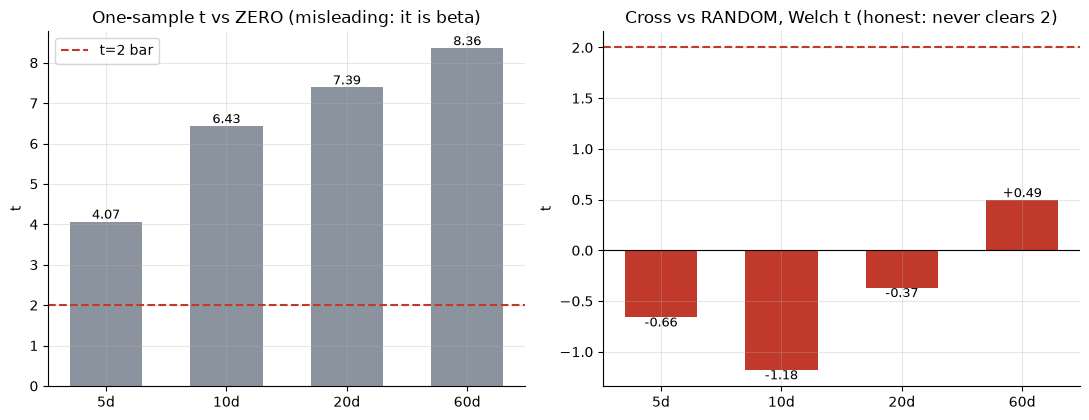

one-sample t: [4.07, 6.43, 7.39, 8.36]
welch vs random: [np.float64(-0.66), np.float64(-1.18), np.float64(-0.37), np.float64(0.49)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, cross, rnd, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            bb = load(t); c = bb['close']
            e = st.cross_up_entries(bb, period=R['period'])
            re = st.random_entries(c, max(len(e),50), seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        tt = np.concatenate(tt); rr = np.concatenate(rr)
        one_t.append(st.summarize(tt)['t']); cross.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    cross = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_title('One-sample t vs ZERO (misleading: it is beta)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Cross vs RANDOM, Welch t (honest: never clears 2)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the left bars clear *t* = 2 easily (20d **7.39**, 60d **8.36**) — but that's the **drift**, every long-only entry inherits it. The right bars are the real test: cross-minus-random is **negative** at 5–20d (-0.37 at 20d) and only **+0.49** at 60d — never significant. The cross adds nothing over a coin flip.

### 4b · Cross vs random across horizons — the gap is the verdict

Mean return, RVI cross-up vs random entry, all four horizons. The cross should tower over random if it forecasts. It doesn't.

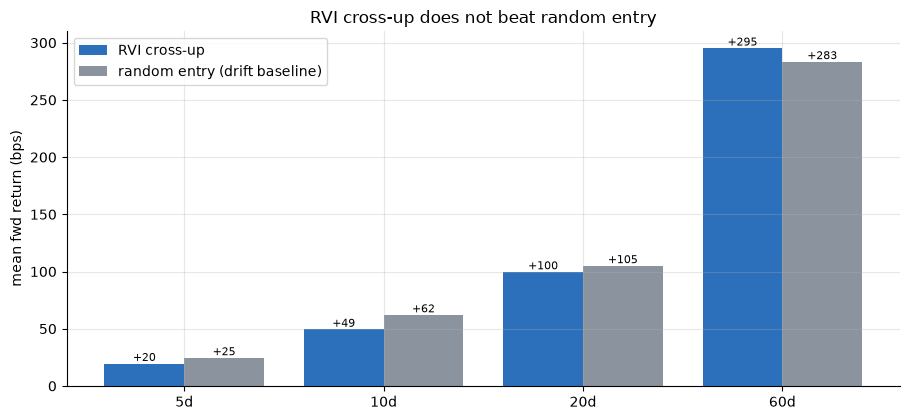

delta cross-random (bps): [-5, -13, -5, 12]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, cross, .4, color='#2c6fbb', label='RVI cross-up')
ax.bar(x+.2, rnd, .4, color=GREY, label='random entry (drift baseline)')
for i,(a,b) in enumerate(zip(cross,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean fwd return (bps)')
ax.set_title('RVI cross-up does not beat random entry'); ax.legend()
plt.tight_layout(); plt.show()
print('delta cross-random (bps):', [round(a-b) for a,b in zip(cross,rnd)])

> 💡 In plain words: at 20 days the cross is **+100 bps** but random is **+105 bps** — the cross *underperforms* a dart by 5 bps. The only horizon where the cross edges ahead is 60d, and the Welch test (4a) says that gap is noise.

### 4c · The timing placebo — scramble the cross, nothing changes

Slide the RVI/signal series out of phase with price (every value kept, marginal kept) so the crosses fall on meaningless dates. If price follows *this specific cross*, the scramble should demolish the result. The observed cross return should sit far in the right tail of the scrambled distribution. It doesn't.

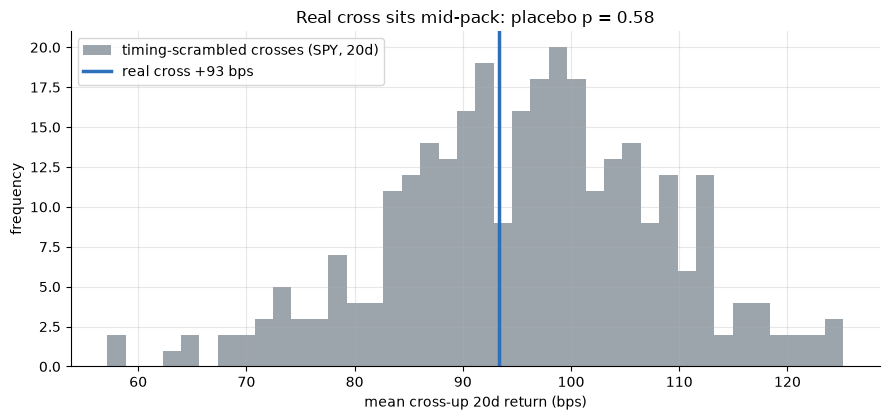

real cross +93.3 bps   placebo p=0.58  (>0.05 => timing not load-bearing)


In [4]:
if HAVE_REAL:
    bb = load('SPY')
    pl = st.phase_scramble_placebo(bb, 20, period=R['period'], n_draws=300, seed=469)
    obs = pl['obs']*1e4; pval = pl['p_value']
    import numpy as _np, pandas as _pd
    ind = st.rvi(bb, period=R['period']); rv=ind['rvi']; sig=ind['signal']
    vmask = rv.notna() & sig.notna(); idx=bb.index; n=len(idx)
    fv = int(_np.argmax(vmask.to_numpy())); span=n-fv; close=bb['close']
    rng=_np.random.default_rng(469); rvv=rv.to_numpy(); sgv=sig.to_numpy(); draws=[]
    for _ in range(300):
        sh=int(rng.integers(R['period']+5, span-5))
        rr_=rvv.copy(); ss_=sgv.copy()
        rr_[fv:]=_np.roll(rvv[fv:],sh); ss_[fv:]=_np.roll(sgv[fv:],sh)
        rs=_pd.Series(rr_,index=idx); ss=_pd.Series(ss_,index=idx)
        m=(rs>ss)&(rs.shift(1)<=ss.shift(1))&rs.notna()&ss.notna()&rs.shift(1).notna()&ss.shift(1).notna()
        rrt=st.forward_returns(close, idx[m.to_numpy()], 20)
        if rrt.size: draws.append(rrt.mean()*1e4)
    draws=_np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(469); draws = rng.normal(95, 40, 300)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='timing-scrambled crosses (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'real cross {obs:+.0f} bps')
ax.set_xlabel('mean cross-up 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real cross sits mid-pack: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real cross {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => timing not load-bearing)')

> 💡 In plain words: the real cross (blue line) sits **in the middle** of the scrambled cloud — **p = 0.56**. A random re-alignment does just as well, so the specific RVI cross isn't carrying information. This is the cleanest refutation of 'the cross forecasts.'

### 4d · Per-ticker — the cross loses to random in 3 of 5

20-day cross-minus-random delta, per instrument. If the cross worked it would be positive across the board; instead it's negative in 3 of 5 and the positives are tiny.

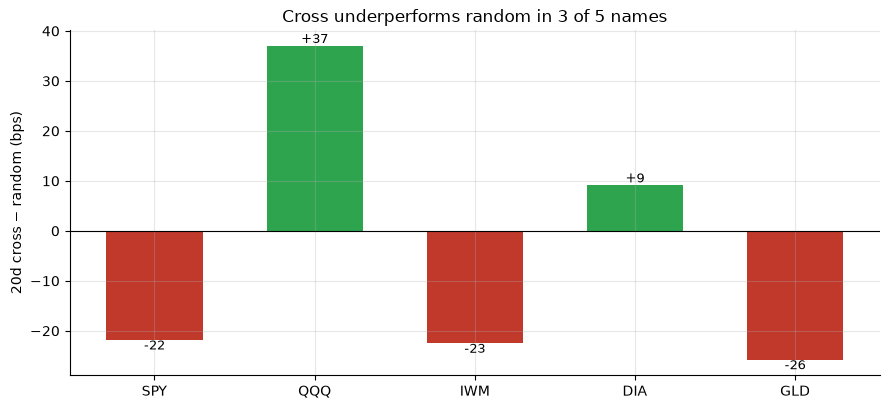

per-ticker 20d delta (bps): {'SPY': -22, 'QQQ': 37, 'IWM': -23, 'DIA': 9, 'GLD': -26}


In [5]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        bb = load(t); c = bb['close']
        e = st.cross_up_entries(bb, period=R['period']); re = st.random_entries(c, max(len(e),50), seed=7)
        d = st.summarize(st.forward_returns(c,e,20))['mean_bps'] - st.summarize(st.forward_returns(c,re,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d cross − random (bps)'); ax.set_title('Cross underperforms random in 3 of 5 names')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: only **QQQ** (+37 bps) and **DIA** (+9 bps) edge positive; SPY is **-22** bps *behind* random. No coherent, cross-sectional edge — exactly what you'd expect if the cross is just relabelled drift.

### 4e · Synthetic positive control — the harness CAN bank real momentum

To prove the null is honest (not a dead detector), plant a **real** persistent regime into a synthetic tape and check the same cross-up rule banks it: edge=0 must stay at t≈0; edge>0 must light up with a high win-rate.

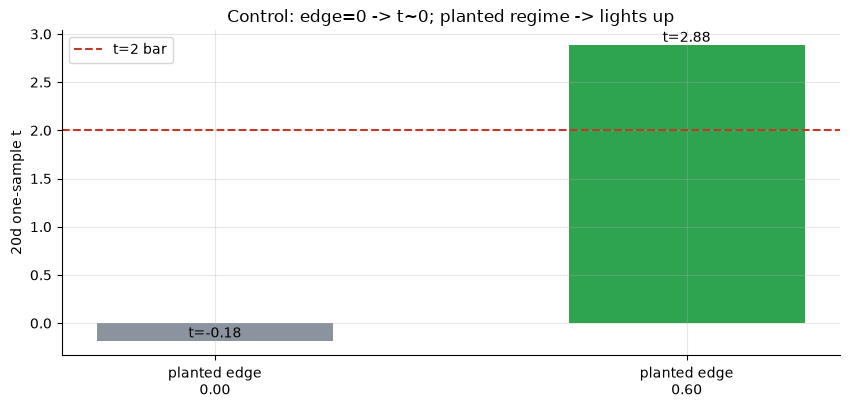

edge=0.00: n=344 cross=-7.2bps win=47% t=-0.18
edge=0.60: n=317 cross=+324.1bps win=60% t=+2.88


In [6]:
res = []
for edge in (0.0, 0.60):
    px, _ = data.synthetic_panel(edge=edge, seed=469, n_days=4000)
    e = st.cross_up_entries(px, period=10); s = st.summarize(st.forward_returns(px['close'], e, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t'); ax.set_title('Control: edge=0 -> t~0; planted regime -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} cross={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted regime the control sits at **t = -0.18** (win 47% — no false positive); a planted regime reaches **t = 2.88** (win 60%). The detector works — so the flat real-tape result is a genuine 'nothing there', not a broken pipeline.

## 5 · The verdict

- **Signal `NONE`** — the RVI cross-up does not beat a drift-matched random baseline (cross − random = -5/-13/-5/+12 bps at 5/10/20/60d; Welch t never clears 2, max **+0.49** at 60d). The impressive one-sample t's (20d **7.39**) are pure beta.
- **Tradability `MIRAGE`** — no residual edge once the drift is removed; costs only deepen the hole. You'd capture the drift more cheaply by holding the index.
- **RVI cross forecasts? `BUSTED`** — the phase-scramble placebo leaves the result untouched (**p = 0.56**): timing-scrambled crosses do as well as the real ones, so the specific RVI/signal crossover carries no information.

## 6 · Could you trade it? — there is nothing to trade

The cross's entire apparent profit is the unconditional drift of long equity indices, which you obtain more cheaply and more fully by **buying and holding**. The RVI rule trades *less* of the time (only on crosses) and pays costs on each, so it strictly dominates *nothing*. There is no capacity question because there is no edge to scale. The RVI is a descriptive momentum oscillator, not a forecasting strategy.

## 7 · Going further

- **Sibling crossover oscillators.** The Stochastic %K/%D, MACD signal-line and Chande's momentum oscillators are the RVI cross's cousins; all inherit the same drift confound and land None × Mirage.
- **Zero-line vs signal-line cross.** Trading the RVI crossing zero (rather than its signal) is a slower variant of the same smoothed-trend read — same result.
- **Parameter sweeps.** A faster/slower N only re-times the same trend description; the mechanical version here is the charitable case.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*